# All Tropical Cyclones

In [1]:
# CIndRA notebook display standard
import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 13,
    'figure.dpi': 100,
    'savefig.dpi': 300,
})


```{glue:figure} tracks_fig
:scale: 40%
:align: left
```


```{glue:figure} time_cat_fig
:scale: 70%
:align: right
```

**Figure. Tropical cyclones (TCs) in the vicinity of Palau since 1950.**  Map showing all TC tracks in the vicinity of Palau (top) and annual storm count (bottom).  Categorizes are colored following the Saffir Simpson scale for wind intensity (see text for details). Grey represents TCs where no wind information is available.  The dashed black line represents a trend that is not statistically significant.   

In this notebook we will analyze the historical tropical cyclones  in the Vicinity of Palau, as well as: <br>
<br>
- The number of tropical cyclones per year <br>
- The trend in the number of tropical cyclones over time <br>
- The distribution of categories over time <br>
- The influence of El Niño Southern Oscillation

## Setup

First, we need to import all the necessary libraries. Some of them are specifically developed to handle the download and plotting of the data and are hosted at the [indicators set-up repository](https://github.com/lauracagigal/indicators_setup) in GitHub

In [2]:
import warnings
warnings.filterwarnings("ignore")
import sys
import os
import os.path as op
from pathlib import Path
import xarray as xr
import pandas as pd
from myst_nb import glue 
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../../../../functions")
from tcs import (Extract_Circle, get_ibtracs_category, Plot_TCs_HistoricalTracks_Category,
                  plot_bar_probs, plot_tc_categories_trend, plot_bar_probs_ONI, add_oni_cat,
                  style_matrix, table_tcs_32a, table_tcs_32b)
from data_downloaders import download_ibtracs, download_oni_index
from site_common import load_site_config, list_available_sites, site_config_filename

sys.path.append("../../../../indicators_setup")


In [3]:
sites_dir = Path("../../../../data/sites")
available_sites = list_available_sites(sites_dir)
print(f"{len(available_sites)} site(s) already configured in {sites_dir}:")
display(available_sites)

6 site(s) already configured in ../../../../data/sites:


,site_key,site_name,country,ghcn_station_id,ghcn_station_name,vars_interest
0,cook_islands_new_zealand_cwm00091843,cook_islands_new_zealand_CWM00091843,Cook Islands [New Zealand],CWM00091843,RAROTONGA INTL GSN 91843,"[TMIN, TMAX, PRCP]"
1,marshall_islands_rmw00040604,marshall_islands_RMW00040604,Marshall Islands,RMW00040604,MH KWAJALEIN GSN 91366,"[TMIN, TMAX, PRCP]"
2,marshall_islands_rmw00040710,marshall_islands_RMW00040710,Marshall Islands,RMW00040710,MH MAJURO WBAS AP GSN 91376,"[TMIN, TMAX, PRCP]"
3,niue_new_zealand_nem00091824,niue_new_zealand_NEM00091824,Niue [New Zealand],NEM00091824,HANAN AIRPORT GSN 91824,"[TMIN, TMAX, PRCP]"
4,palau,Palau,Palau,None,None,None
5,palau_psw00040309,palau_PSW00040309,Palau,PSW00040309,PW KOROR GSN 91408,"[TMIN, TMAX, PRCP]"


In [4]:
site_key = "palau_psw00040309"  # pick a site_key from the table printed above

site_config_path = sites_dir / site_config_filename(site_key)
site_cfg = load_site_config(site_config_path)

site_name = site_cfg.get('site_name', 'Site')
site_lon = float(site_cfg.get('site_lon'))
site_lat = float(site_cfg.get('site_lat'))
country = site_cfg.get('country', site_cfg.get('station_country_filter', 'Country'))

lon_lat = [site_lon, site_lat]  # site location: lon, lat
basin = 'WP'
r1 = 5 # Radius of the circular area in degrees

## IBTrACS
IBTrACS (International Best Track Archive for Climate Stewardship) is the most comprehensive global database of tropical cyclones. It compiles data from all major meteorological agencies worldwide, providing track, intensity, and metadata for storms from 1842 to present. It supports research on cyclone trends, risks, and climate variability.

In [5]:
update_data = True
path_data = "../../../../data/tcs"
path_figs = "../../../../matrix_cc/figures"

os.makedirs(path_data, exist_ok=True)

In [6]:
if update_data:
    url = 'https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r01/access/netcdf/IBTrACS.ALL.v04r01.nc'
    tcs = download_ibtracs(url, basin = basin)
    tcs.to_netcdf(f"{path_data}/tcs_{basin}.nc")
else:
    tcs = xr.load_dataset(f"{path_data}/tcs_{basin}.nc")

## Analysis

In [7]:
tcs = tcs.isel(storm = np.where(tcs.isel(date_time = 0).time.dt.year >= 1950)[0])    

In [8]:
# tcs = xr.open_dataset('/Users/laurac/Downloads/IBTrACS.ALL.v04r01.nc')

In [9]:
d_vns = {
    'longitude': 'lon',
    'latitude': 'lat',
    'time': 'time',
    'pressure': 'wmo_pres',
    'wind': 'wmo_wind',
}
tcs_sel, tcs_sel_params = Extract_Circle(tcs, lon_lat[0], lon_lat[1], r1, d_vns, fillwinds=True)

In [10]:
tcs_WP = get_ibtracs_category(tcs, d_vns)

The static plot below shows all the TCs in the vicinity of Palau colored by its category.

In [11]:
tcs_sel_params['category'] = (('storm'), np.where(np.isnan(tcs_sel_params.category), -1, tcs_sel_params.category))
tcs_WP['category'] = (('storm'), np.where(np.isnan(tcs_WP.category), -1, tcs_WP.category))

## Plotting

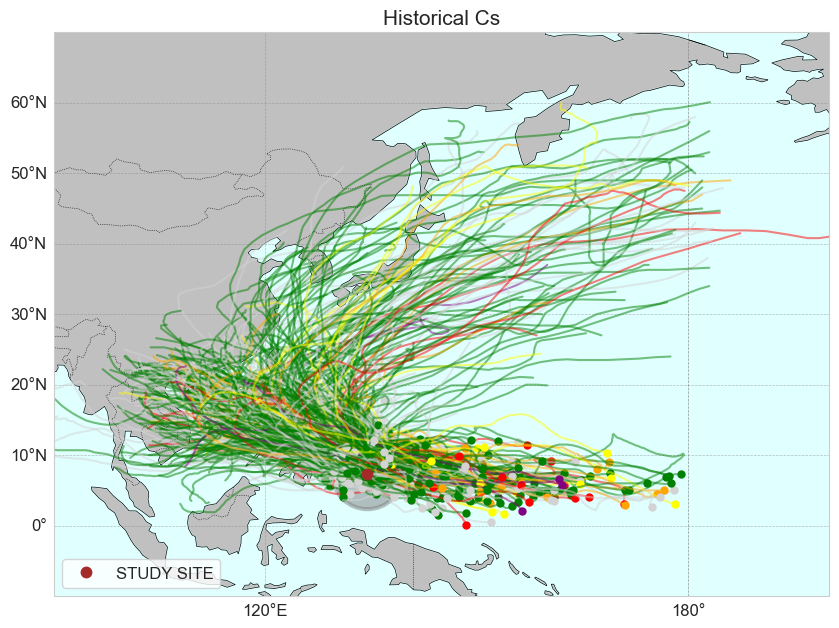

In [12]:
lon1, lon2 = 90, 200
lat1, lat2 = -10, 70

# r1
fig, ax = Plot_TCs_HistoricalTracks_Category(
    tcs_sel, tcs_sel_params.category,
    lon1, lon2, lat1, lat2,
    lon_lat[0], lon_lat[1], r1,
)

plt.savefig(op.join(path_figs, 'F8_TCs_Historical.png'), dpi=300, bbox_inches='tight')
glue("tracks_fig", fig, display=False)


Plot of the TC count per month showing the seasonality of TC genesis in the area

Text(0.5, 0, 'Month')

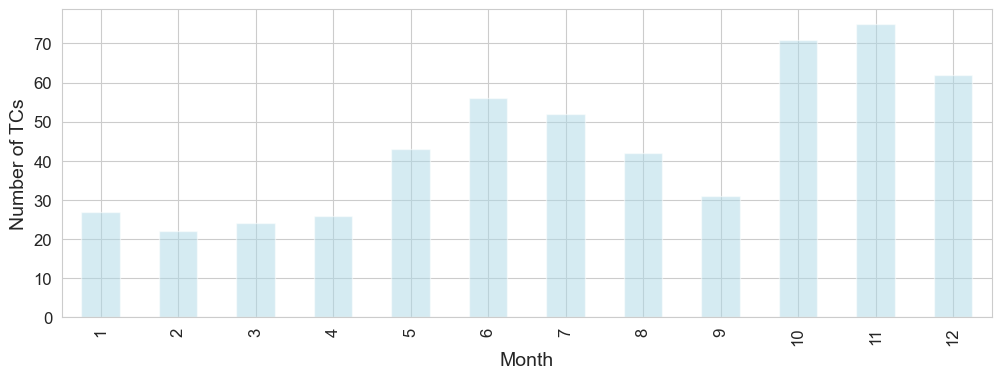

In [13]:
import matplotlib.pyplot as plt
tcs_sel_params['month'] =  tcs_sel_params.dmin_date.dt.month
tcs_sel_params.to_dataframe().groupby('month').count().index_in.plot.bar(figsize = (12, 4), color = 'lightblue', alpha = .5)
plt.ylabel('Number of TCs', fontsize = 14)
plt.xlabel('Month', fontsize = 14)

## Count TCs by category

The bar plot below displays the TC count per category in the whole record and also to the record limited to 1979 and after.

In [14]:
u, c = np.unique(tcs_sel_params.category, return_counts=True)

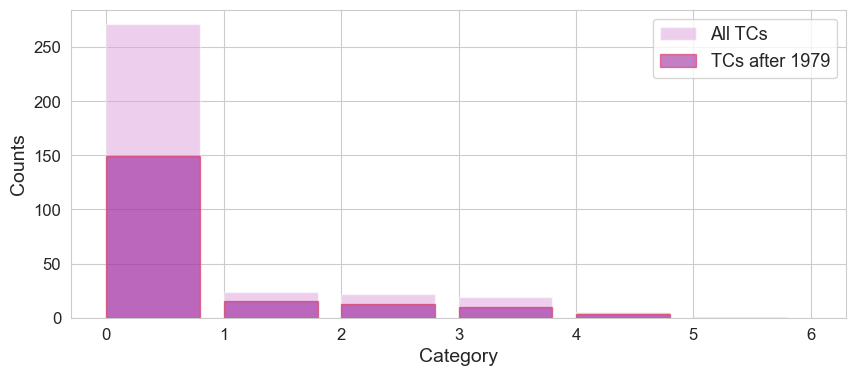

In [15]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, figsize=(10, 4))
ax.grid(zorder = -1)
tcs_sel_params.category.plot.hist(bins=range(7), ax=ax, color='plum', alpha=0.5, edgecolor= None, width = .8, linewidth=1, label = 'All TCs')
tcs_sel_params.where(tcs_sel_params.dmin_date.dt.year >=1979, 
                     drop = True).category.plot.hist(bins=range(7), ax=ax, 
                                                     color='darkmagenta', alpha=0.5, edgecolor='crimson', width = .8, linewidth=1, label = 'TCs after 1979')
ax.set_xlabel('Category')
ax.set_ylabel('Counts')

ax.legend()

The plot below shows the trend of the number of TCs per year over time.

(<Figure size 1500x400 with 1 Axes>, <Axes: ylabel='Number TCs'>)

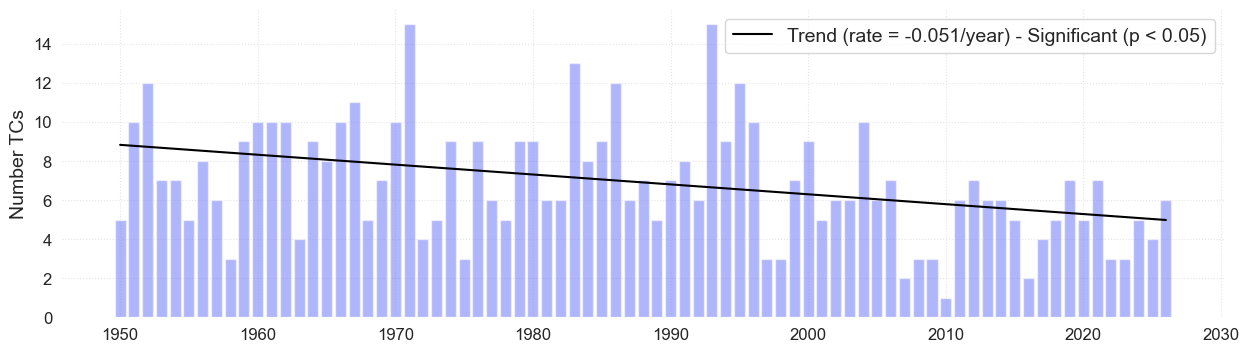

In [16]:
time = tcs_sel_params.dmin_date.dt.year.values
u, cu = np.unique(time, return_counts=True)
plot_bar_probs(x = u, y = cu, figsize= (15, 4), trendline = True,
               y_label =  'Number TCs')

The following bar plot displays the TC count per year and per category, as well as the trend. <br>
 The grey color represent those TCs in the record where no pressure or wind information is available to determine the corresponding category.

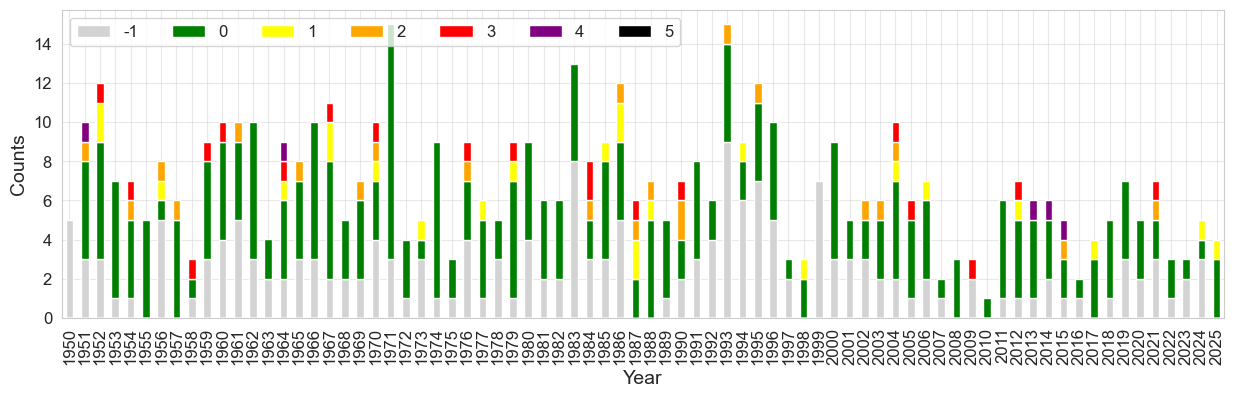

In [17]:
fig = plot_tc_categories_trend(tcs_sel_params, trendline_plot = False)
plt.savefig(op.join(path_figs, 'F8_TCs_Historical_bars_category.png'), dpi=300, bbox_inches='tight')
glue("time_cat_fig", fig, display=False)


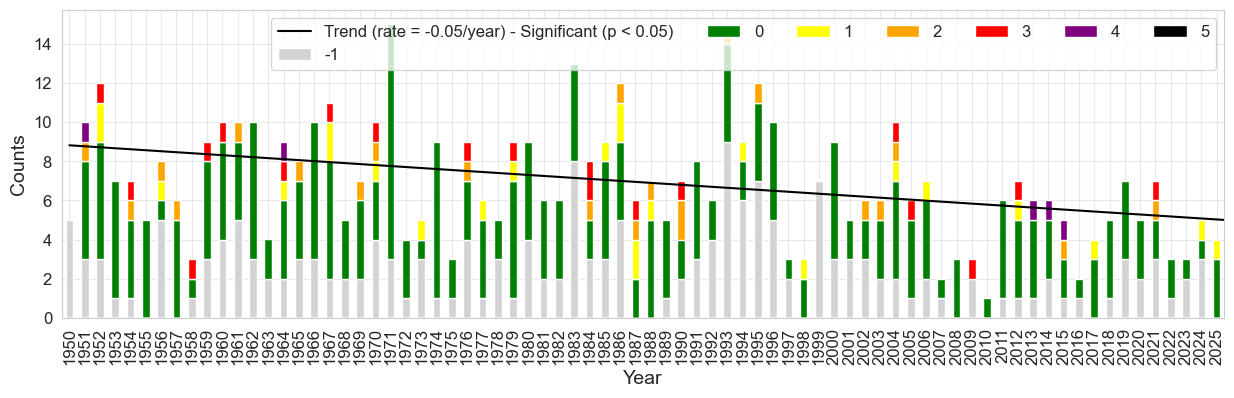

In [18]:
fig = plot_tc_categories_trend(tcs_sel_params, trendline_plot = True)
plt.savefig(op.join(path_figs, 'F8_TCs_Historical_bars_category.png'), dpi=300, bbox_inches='tight')
glue("time_cat_fig", fig, display=False)


To showcase the spatial distribution of the TC tracks for the different categories, a map is shown below representing all the TCs in the record for each category.

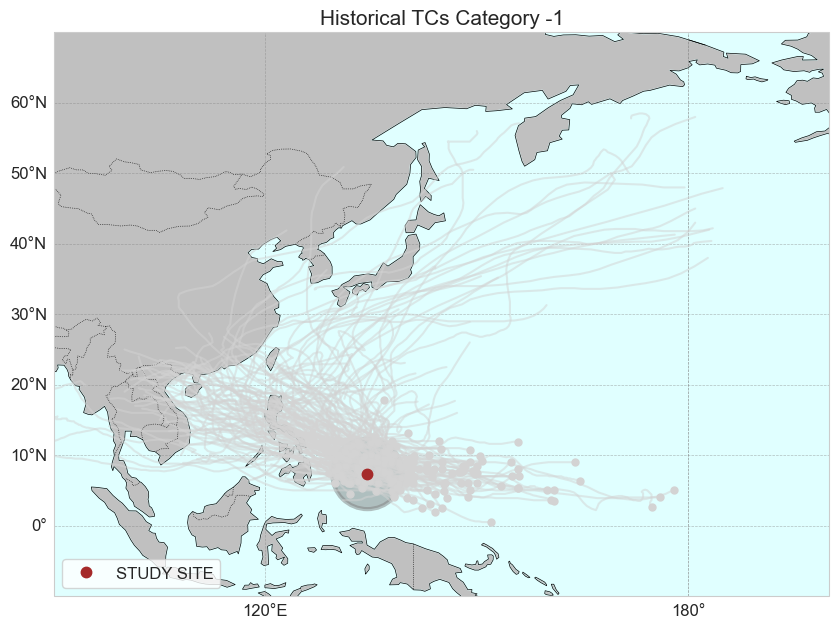

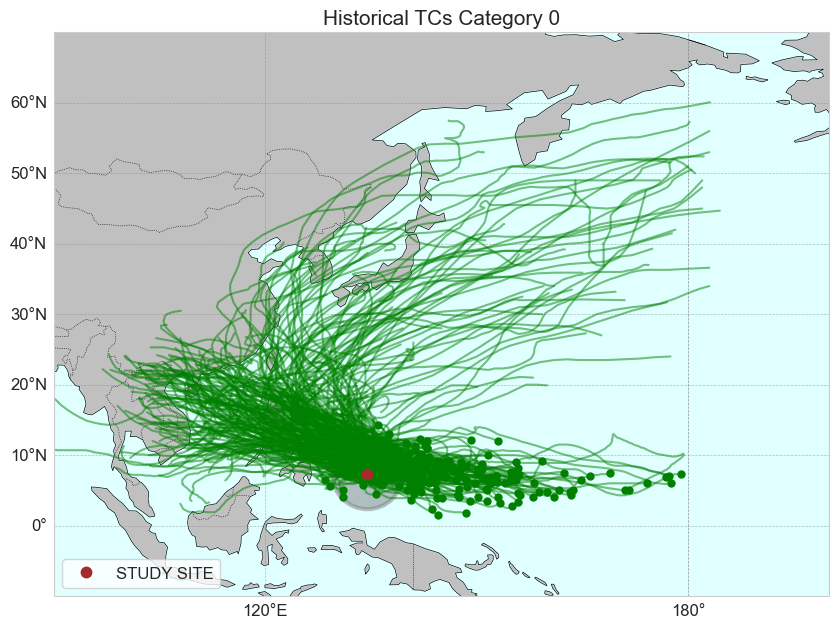

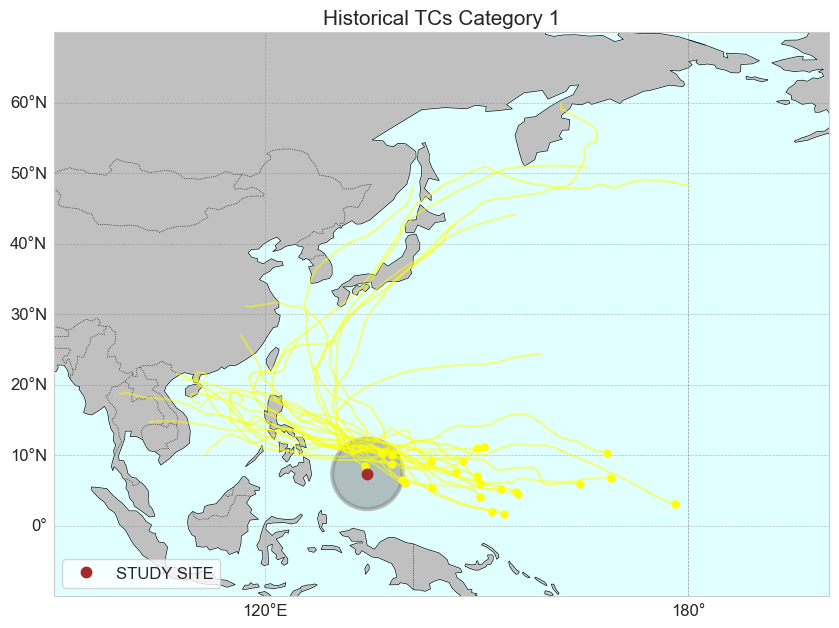

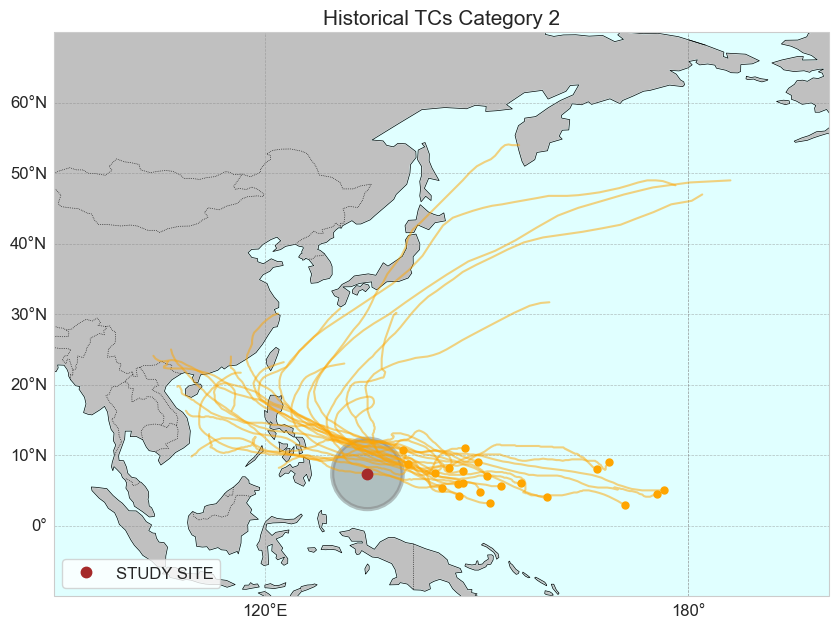

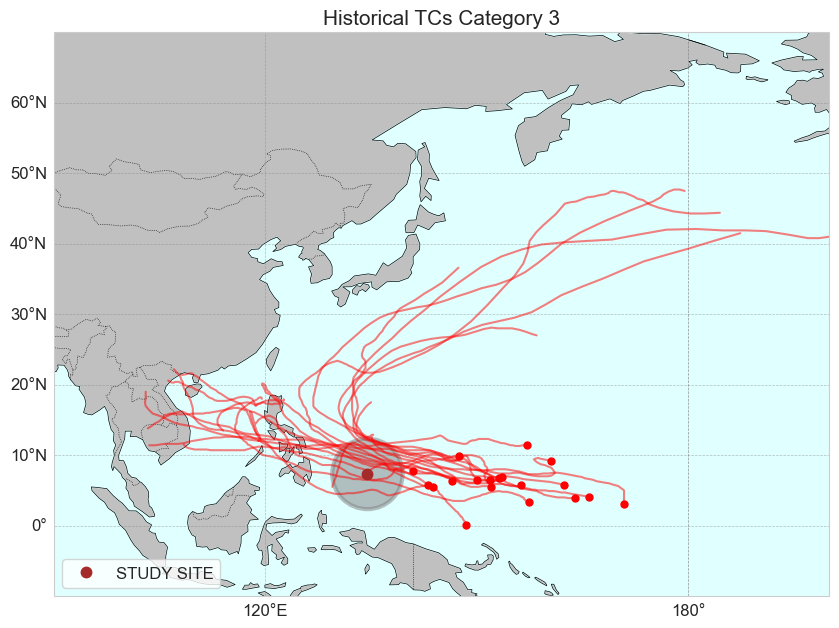

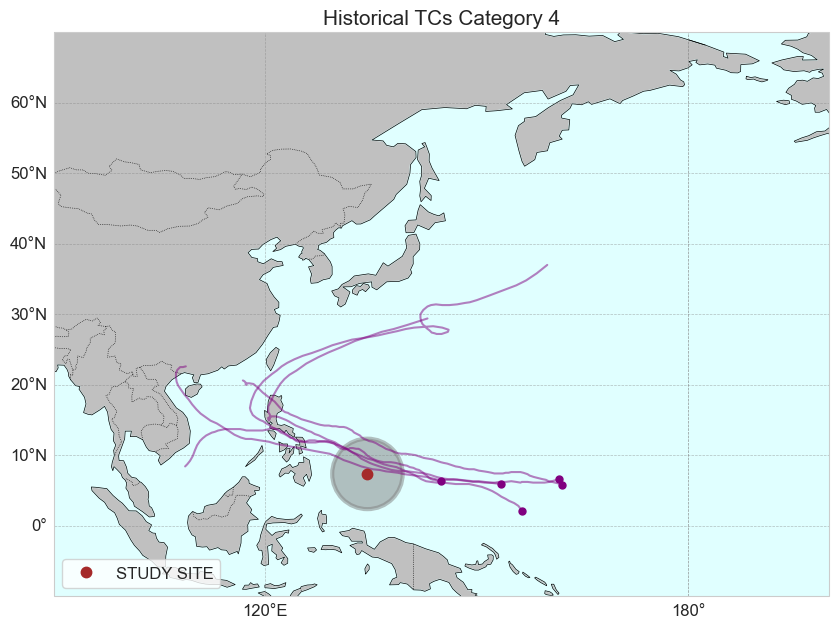

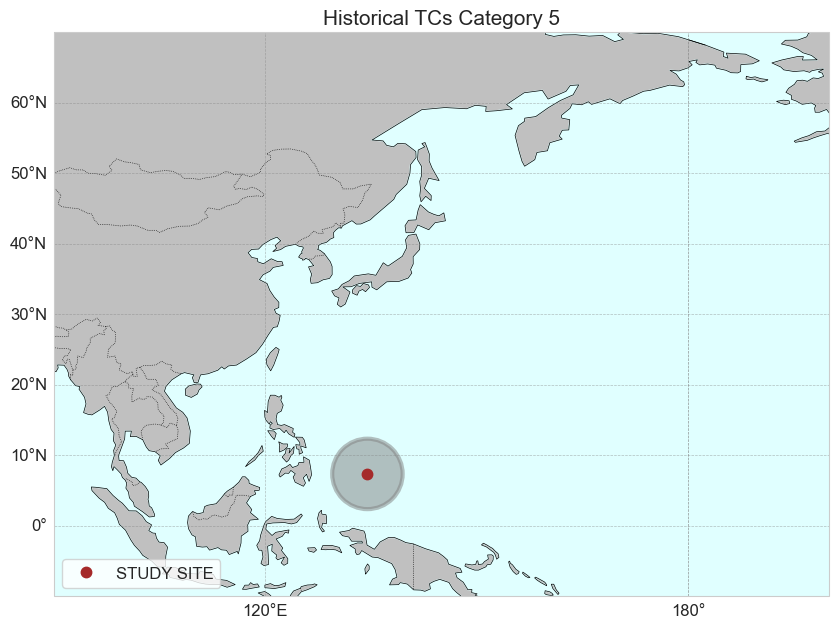

In [19]:

for category in np.arange(-1, 6, 1):

    tcs_cat = tcs_sel.where(tcs_sel_params.category == category, drop = True)
    tcs_cat_params = tcs_sel_params.where(tcs_sel_params.category == category, drop = True)

    # r1
    fig, ax = Plot_TCs_HistoricalTracks_Category(
        tcs_cat, tcs_cat_params.category,
        lon1, lon2, lat1, lat2,
        lon_lat[0], lon_lat[1], r1,
    )
    ax.set_title(f'Historical TCs Category {category}', fontsize=15)

### Generate table
Table sumarizing different metrics of the data analyzed in the plots above <br>
Number of TCs for each category

In [20]:
df_tcs = tcs_sel_params.to_dataframe()
df_tcs['year'] = df_tcs.dmin_date.dt.year
df_t = df_tcs.groupby('category').count()[['pressure_min']]
# fig = plot_df_table(df_t, figsize = (300, 220))

mean_tcs_per_year = df_tcs.groupby(df_tcs['dmin_date'].dt.year)['pressure_min'].count()

df_sev = df_tcs.loc[df_tcs['category'] >=3]
mean_tcs_per_year_sev = df_sev.groupby(df_sev['dmin_date'].dt.year)['pressure_min'].count()

print('Mean TCs per year: ', np.nanmean(mean_tcs_per_year))
print('Mean number of severe TCs per year: ', np.round(np.nanmean(mean_tcs_per_year_sev), 2))


Mean TCs per year:  4.428571428571429
Mean number of severe TCs per year:  1.09


## ONI index

The Oceanic Niño Index (ONI) is the standard measure used to monitor El Niño and La Niña events. It is based on sea surface temperature anomalies in the central equatorial Pacific (Niño 3.4 region) averaged over 3-month periods. 

https://origin.cpc.ncep.noaa.gov/products/analysis_monitoring/ensostuff/ONI_v5.php

In [21]:
p_data = 'https://psl.noaa.gov/data/correlation/oni.data'

In [22]:
if update_data:
    df1 = download_oni_index(p_data)
    df1.to_pickle(op.join(path_data, 'oni_index.pkl'))
else:
    df1 = pd.read_pickle(op.join(path_data, 'oni_index.pkl'))

oni = df1

In [23]:
lims = [-.5, .5]
df1 = add_oni_cat(df1, lims = lims)

In [24]:
import pandas as pd
tcs_g = pd.DataFrame(tcs_sel.isel(date_time = 0).time.values)
tcs_g.index = tcs_g[0]
tcs_g.index = pd.DatetimeIndex(tcs_g.index).to_period('M').to_timestamp() + pd.offsets.MonthBegin(0)
tcs_g['oni_cat'] = oni.oni_cat

In [25]:
print('Number of La Niña years:', len(oni.loc[oni.oni_cat == -1].index.year.unique()))
print('Number of El Niño years:', len(oni.loc[oni.oni_cat == 1].index.year.unique()))
print('Number of Neutral years:', len(oni.loc[oni.oni_cat == 0].index.year.unique()))

Number of La Niña years: 24
Number of El Niño years: 22
Number of Neutral years: 30


In [26]:
tcs_sel_params['oni_cat'] = (('storm'), tcs_g['oni_cat'].values)
tcs_sel['oni_cat'] = (('storm'), tcs_g['oni_cat'].values)

In [27]:
# oni['ONI_cat'] = np.where(oni.ONI < lims[0], -1, np.where(oni.ONI > lims[1], 1, 0))
tcs_sel_params['oni_cat'] = (('storm'), tcs_sel.oni_cat.values)

In [28]:
oni_perc_cat = oni.groupby('oni_cat').size() / oni.shape[0] * 100
oni_perc_cat

oni_cat
-1    31.578947
 0    39.473684
 1    28.947368
dtype: float64

In [29]:
tcs_perc_cat = tcs_sel_params.to_dataframe().groupby('oni_cat').size() * 100 / tcs_sel_params.to_dataframe().shape[0]
tcs_perc_cat

oni_cat
-1.0    29.755179
 0.0    43.691149
 1.0    25.612053
dtype: float64

In [30]:
#Relavice probability
tcs_perc_cat / oni_perc_cat

oni_cat
-1.0    0.942247
 0.0    1.106842
 1.0    0.884780
dtype: float64

In [31]:
time = tcs_sel_params.dmin_date.dt.year.values
u, cu = np.unique(time, return_counts=True)
tc_c = pd.DataFrame(cu, index = u)
time_sev = tcs_sel_params.where(tcs_sel_params.category >= 3, drop = True).dmin_date.dt.year.values
u_sev, cu_sev = np.unique(time_sev, return_counts=True)
tc_c_sev = pd.DataFrame(cu_sev, index = u_sev)

In [32]:
oni_y = oni.groupby(oni.index.year).min()
oni_y['tc_counts'] = tc_c
oni_y['tc_counts_sev'] = tc_c_sev

In [33]:
oni_y['oni_cat'] = oni_y.oni_cat.values

The following bar plot represents the TC counts over time. The color of the bar represents wether it is a El Niño or La Niña year.

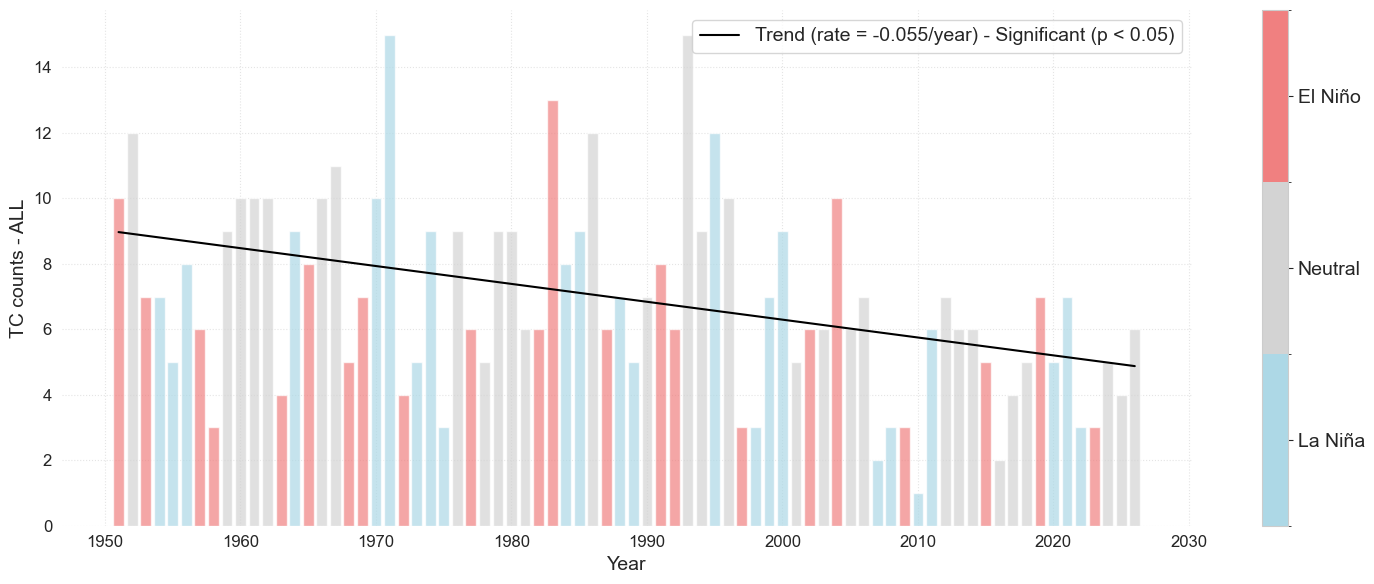

In [34]:
ax = plot_bar_probs_ONI(oni_y, 'tc_counts', y_label= 'TC counts - ALL');

The following bar plot represents the severe TC counts over time. The color of the bar represents wether it is a El Niño or La Niña year.

## ALL TCs

The following plots represent all the TCs in the record for the three different phases of the El Niño Southern Oscillation: "El Niño", "Neutral" and "La Niña"

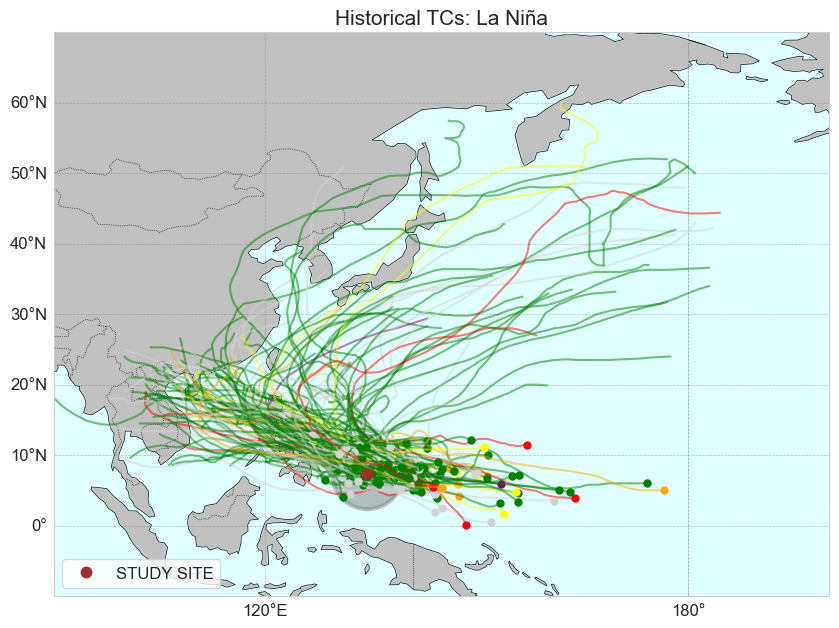

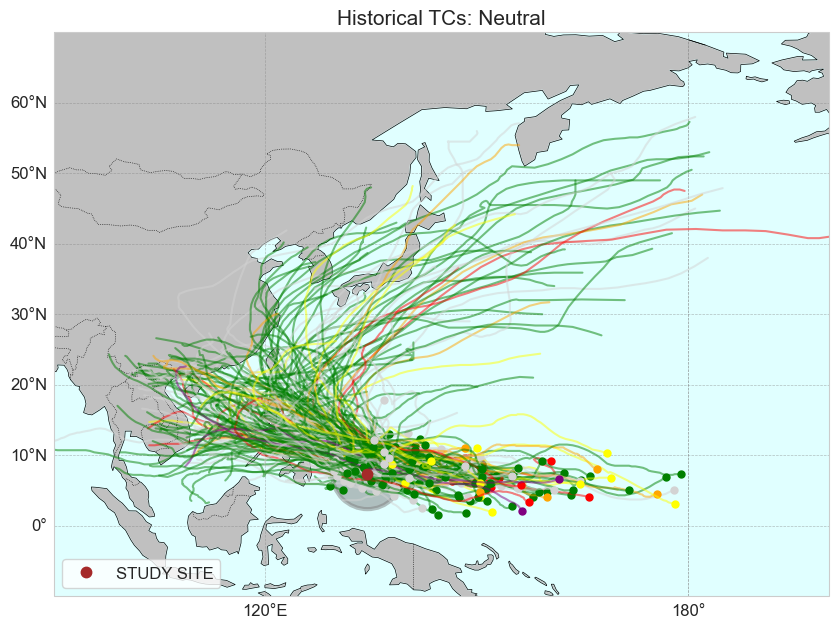

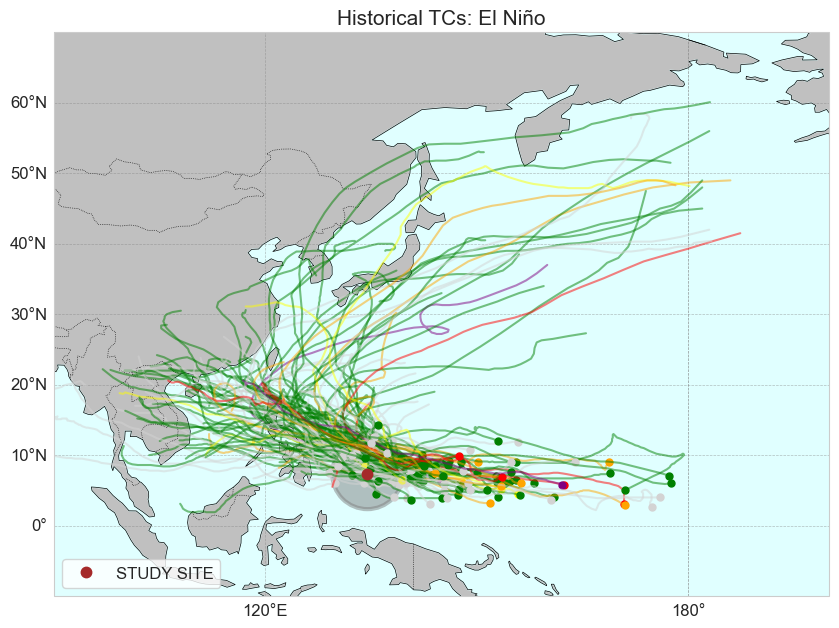

In [35]:
names_cat = ['La Niña', 'Neutral', 'El Niño']

for ic, category in enumerate([-1, 0, 1]):

    tcs_cat = tcs_sel.where(tcs_sel_params.oni_cat == category, drop = True)
    tcs_cat_params = tcs_sel_params.where(tcs_sel_params.oni_cat == category, drop = True)

    fig, ax = Plot_TCs_HistoricalTracks_Category(
        tcs_cat, tcs_cat_params.category,
        lon1, lon2, lat1, lat2,
        lon_lat[0], lon_lat[1], r1,
    )
    ax.set_title(f'Historical TCs: {names_cat[ic]}', fontsize=15)

    plt.savefig(op.join(path_figs, f'F9_TCs_{names_cat[ic]}.png'), dpi=300, bbox_inches='tight')


## Generate table
Table sumarizing different metrics of the data analyzed in the plots above

In [36]:
# TC table helpers are imported from tcs above.

In [37]:
style_matrix(table_tcs_32a(tcs_sel_params, oni), title = 'Key TC Metrics: Vicinity of Palau')

Metric,Value
Total number of tracks,531.000
Tropical Storms per year,6.896
Standard deviation of storms per year,2.957
Maximum number of storms in a year 1971,15.000
Minimum number of storms in a year 2010,1.000
Major Hurricanes (Category 3+) per year,0.312
Standard deviation of major hurricanes per year,0.287
Maximum number of major hurricanes in a year 1964,2.000
Minimum number of major hurricanes in a year 1951,1.000
,


In [38]:
style_matrix(table_tcs_32b(tcs_WP, oni), title = 'Key TC Metrics: West Pacific Basin')

Metric,Value
Total number of tracks,2687.000
Tropical Storms per year,34.896
Standard deviation of storms per year,7.618
Maximum number of storms in a year 1971,55.000
Minimum number of storms in a year 2023,19.000
Major Hurricanes (Category 3+) per year,6.104
Standard deviation of major hurricanes per year,2.584
Maximum number of major hurricanes in a year 2015,14.000
Minimum number of major hurricanes in a year 1998,1.000
,


## Interpretation and reproducibility notes

- Results apply to the configured station, site or EEZ and should not be generalized without checking spatial representativeness.
- Changes in observing practices and best-track quality can affect historical cyclone counts and intensity estimates.
- Linear trends are descriptive unless the notebook explicitly accounts for temporal autocorrelation and other statistical assumptions.
- Confirm the printed source, analysis period, reference period and output paths before using figures or tables in reporting.